# Momentum Factor

Explore the 12-month momentum signal using the reusable factor functions from `src.factors`.

In [2]:
import os
import sys

import pandas as pd
from scipy.stats import zscore

sys.path.append(os.path.abspath(".."))

from src.factors import calculate_momentum, select_top_n

In [3]:
prices = pd.read_csv(
    "../data/prices.csv",
    index_col=0,
    parse_dates=True,
)

prices.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.267067,136.742584,59.450500,88.292412,282.886444,131.293930,102.634384,30.269533,88.640511,106.224533,...,78.699913,56.421844,4.922530,72.280701,127.825684,110.094940,191.993927,107.888268,33.712959,28.800236
2018-01-03,40.260056,139.322922,60.209999,88.836761,283.801239,131.494583,103.499405,30.511000,89.286644,106.680588,...,79.066154,56.412956,5.246499,72.193016,128.338608,110.445290,194.007950,108.962341,33.020180,29.051460
2018-01-04,40.447071,138.735779,60.479500,90.314377,282.724426,133.300430,104.865768,30.597324,89.008743,106.633102,...,79.762062,56.377396,5.274155,72.703300,127.640305,110.445290,194.850067,109.367455,33.127235,29.077755
2018-01-05,40.907574,139.562393,61.457001,90.520378,294.322296,135.407272,106.261612,31.021099,88.862823,106.053513,...,80.750977,56.857292,5.318851,72.751152,130.285141,110.245102,198.565598,111.986679,33.051666,29.250099
2018-01-08,40.755630,139.523743,62.343498,89.687538,295.570740,138.810013,107.008705,31.342840,89.300529,104.533279,...,80.833359,57.363834,5.481824,73.133881,131.008148,109.652817,195.119110,112.438934,32.994987,29.682446


In [4]:
momentum = calculate_momentum(prices, lookback=252)
latest_momentum = momentum.iloc[-1].dropna()

latest_momentum.sort_values(ascending=False)

NVDA    1.712493
WMT     0.739923
AXP     0.603201
GS      0.520313
MMM     0.461244
AMZN    0.443925
JPM     0.442881
IBM     0.392704
AAPL    0.307052
TRV     0.287584
CRM     0.277637
CAT     0.246586
DIS     0.244428
V       0.223183
CSCO    0.209956
PG      0.172538
HD      0.149957
VZ      0.131426
MSFT    0.129273
HON     0.100156
SHW     0.099002
KO      0.088775
CVX     0.012871
MCD     0.001366
UNH    -0.024104
JNJ    -0.048115
MRK    -0.062601
AMGN   -0.067719
NKE    -0.291075
BA     -0.320955
Name: 2024-12-31 00:00:00, dtype: float64

<Axes: title={'center': 'Top 10 Stocks by 12-Month Momentum'}>

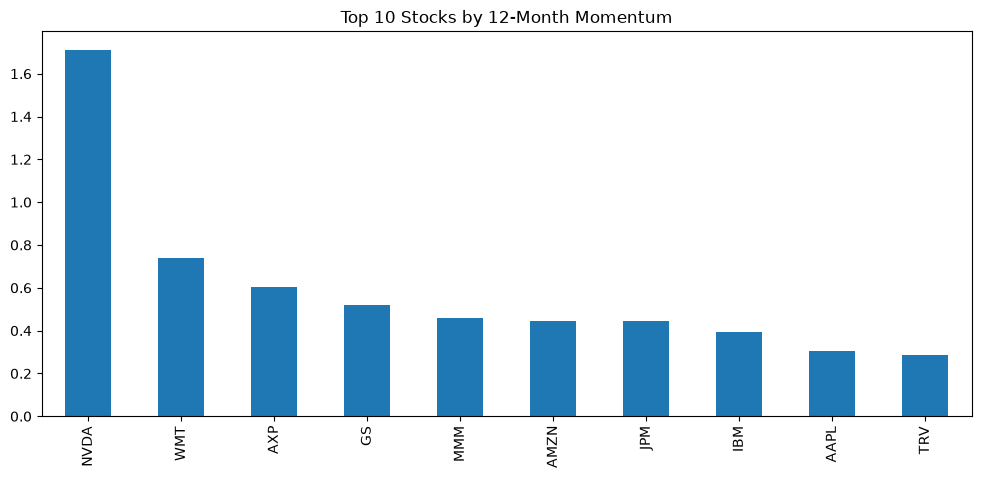

In [5]:
top10 = select_top_n(latest_momentum, n=10)

latest_momentum.loc[top10].plot(
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Stocks by 12-Month Momentum",
)

In [6]:
rankings = (
    latest_momentum
    .sort_values(ascending=False)
    .rename("Momentum")
    .reset_index()
    .rename(columns={"index": "Ticker"})
)

rankings.to_csv(
    "../data/momentum_rankings.csv",
    index=False,
)

rankings.head(10)

,Ticker,Momentum
0,NVDA,1.712493
1,WMT,0.739923
2,AXP,0.603201
3,GS,0.520313
4,MMM,0.461244
5,AMZN,0.443925
6,JPM,0.442881
7,IBM,0.392704
8,AAPL,0.307052
9,TRV,0.287584


<Axes: >

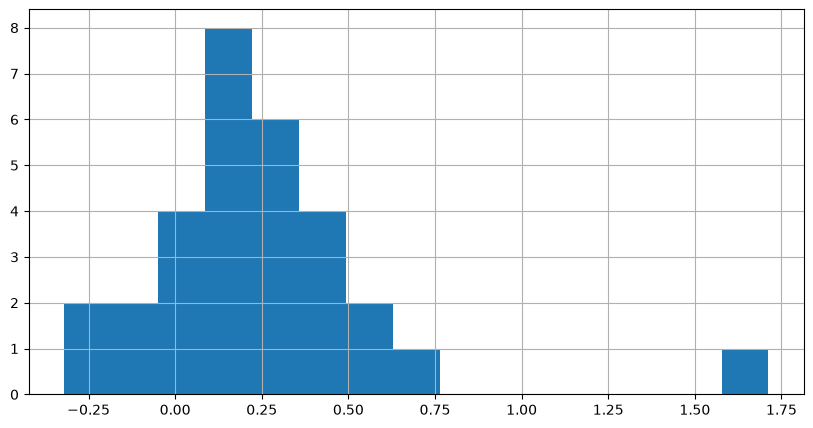

In [7]:
latest_momentum.hist(
    bins=15,
    figsize=(10, 5),
)

The momentum distribution is positively skewed, with most stocks exhibiting 12-month returns between 0% and 50%. NVDA and other strong outperformers create a long right tail, which is consistent with equity returns where a few stocks can account for a disproportionate share of market gains. This suggests that normalization techniques such as z-scores may be useful when constructing factor rankings.

In [8]:
momentum_z = pd.Series(
    zscore(latest_momentum),
    index=latest_momentum.index,
    name="momentum_z",
)

momentum_z.sort_values(ascending=False)

NVDA    4.066538
WMT     1.381600
AXP     1.004157
GS      0.775332
MMM     0.612261
AMZN    0.564449
JPM     0.561568
IBM     0.423046
AAPL    0.186590
TRV     0.132845
CRM     0.105383
CAT     0.019664
DIS     0.013704
V      -0.044946
CSCO   -0.081461
PG     -0.184759
HD     -0.247097
VZ     -0.298255
MSFT   -0.304198
HON    -0.384581
SHW    -0.387769
KO     -0.416000
CVX    -0.625545
MCD    -0.657307
UNH    -0.727621
JNJ    -0.793907
MRK    -0.833898
AMGN   -0.848029
NKE    -1.464638
BA     -1.547126
Name: momentum_z, dtype: float64

In [9]:
factor_table = pd.DataFrame({
    "momentum": latest_momentum,
    "momentum_z": momentum_z,
}).sort_values(
    "momentum_z",
    ascending=False,
)

factor_table.to_csv("../data/factor_table.csv")

factor_table

,momentum,momentum_z
NVDA,1.712493,4.066538
WMT,0.739923,1.381600
AXP,0.603201,1.004157
GS,0.520313,0.775332
MMM,0.461244,0.612261
AMZN,0.443925,0.564449
JPM,0.442881,0.561568
IBM,0.392704,0.423046
AAPL,0.307052,0.186590
TRV,0.287584,0.132845


<Axes: title={'center': 'Momentum Z-Scores'}>

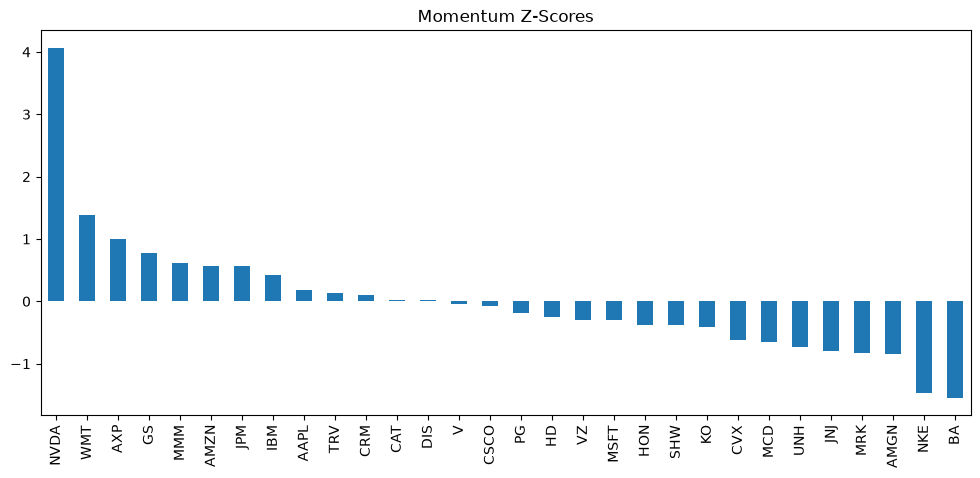

In [10]:
factor_table["momentum_z"].plot(
    kind="bar",
    figsize=(12, 5),
    title="Momentum Z-Scores",
)